# Semiconductor Equipment Health Monitor
## Multivariate Sensor Anomaly Detection + LLM-Powered Diagnostics

**Domain:** Semiconductor Manufacturing Equipment  

### Problem
Semiconductor manufacturing equipment generates continuous sensor streams — temperature, pressure, gas flow, RF power. 
Equipment drift or failure shows up in sensor data before visible defects occur. Early detection prevents costly downtime.

### Approach
- **Part 1:** Simulate realistic multivariate sensor time-series data with injected anomalies
- **Part 2:** Detect anomalies using statistical methods and Isolation Forest (scikit-learn)
- **Part 3:** LLM-powered diagnostic explanation of detected anomalies

### Physical Systems Context
Each sensor maps to a real physical process:
- **Temperature** → chamber thermal stability, heater performance
- **Pressure** → gas flow dynamics, vacuum integrity
- **RF Power** → plasma generation efficiency
- **Gas Flow** → precursor delivery, reaction stoichiometry

In [26]:
# ── IMPORTS ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## Part 1 — Simulate Semiconductor Equipment Sensor Data

In [27]:
# ── SIMULATE SENSOR DATA ─────────────────────────────────────────────────
n_points = 1000
time = np.arange(n_points)

# Normal operating conditions with realistic noise
# CVD chamber: temperature ~300°C, pressure ~10 mTorr, RF ~500W, gas flow ~100 sccm
temperature = 300 + 2 * np.sin(0.05 * time) + np.random.normal(0, 0.8, n_points)
pressure    = 10  + 0.5 * np.sin(0.03 * time) + np.random.normal(0, 0.1, n_points)
rf_power    = 500 + 3 * np.sin(0.07 * time) + np.random.normal(0, 1.5, n_points)
gas_flow    = 100 + np.random.normal(0, 0.5, n_points)

# ── INJECT ANOMALIES ─────────────────────────────────────────────────────
# Anomaly 1 (t=200-215): Temperature spike → heater malfunction
temperature[200:215] += 18

# Anomaly 2 (t=450-460): Pressure drop → vacuum leak
pressure[450:460] -= 4
gas_flow[450:460] += 15  # compensatory gas flow increase

# Anomaly 3 (t=700-710): RF power instability → plasma irregularity
rf_power[700:710] -= 80
rf_power[710:720] += 60

# Anomaly 4 (t=850-855): Multi-sensor event → potential process failure
temperature[850:855] += 12
pressure[850:855]    -= 2
rf_power[850:855]    -= 40

# Ground truth labels (1 = anomaly)
labels = np.zeros(n_points, dtype=int)
for idx in [range(200,215), range(450,460), range(700,720), range(850,855)]:
    labels[idx] = 1

# Build DataFrame
df = pd.DataFrame({
    'time':        time,
    'temperature': temperature,
    'pressure':    pressure,
    'rf_power':    rf_power,
    'gas_flow':    gas_flow,
    'true_anomaly': labels
})

print(f'Dataset shape: {df.shape}')
print(f'Total anomaly points: {labels.sum()} ({labels.mean()*100:.1f}%)')
df.describe().round(2)

Dataset shape: (1000, 6)
Total anomaly points: 50 (5.0%)


,time,temperature,pressure,rf_power,gas_flow,true_anomaly
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,499.50,300.35,9.97,499.62,100.14,0.05
std,288.82,2.70,0.52,10.76,1.56,0.22
min,0.00,296.08,6.27,417.53,98.55,0.00
25%,249.75,298.71,9.66,497.99,99.63,0.00
50%,499.50,300.16,10.02,499.92,100.01,0.00
75%,749.25,301.44,10.35,502.15,100.35,0.00
max,999.00,319.37,10.69,561.10,116.03,1.00


## Part 2 — Anomaly Detection

In [28]:
# ── STATISTICAL BASELINE: ROLLING Z-SCORE ────────────────────────────────
sensors = ['temperature', 'pressure', 'rf_power', 'gas_flow']
window  = 50
z_threshold = 3.0

for sensor in sensors:
    roll_mean = df[sensor].rolling(window, min_periods=1).mean()
    roll_std  = df[sensor].rolling(window, min_periods=1).std().fillna(1)
    df[f'{sensor}_zscore'] = (df[sensor] - roll_mean) / roll_std

zscore_cols = [f'{s}_zscore' for s in sensors]
df['stat_anomaly'] = (df[zscore_cols].abs() > z_threshold).any(axis=1).astype(int)

print(f'Statistical method detected: {df["stat_anomaly"].sum()} anomaly points')

Statistical method detected: 32 anomaly points


In [29]:
# ── ISOLATION FOREST ─────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[sensors])

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)
iso_pred = iso_forest.fit_predict(X_scaled)
df['iso_anomaly'] = (iso_pred == -1).astype(int)

# Anomaly score (lower = more anomalous)
df['anomaly_score'] = iso_forest.score_samples(X_scaled)

print(f'Isolation Forest detected: {df["iso_anomaly"].sum()} anomaly points')

Isolation Forest detected: 50 anomaly points


In [30]:
# ── COMBINED DETECTION ────────────────────────────────────────────────────
df['combined_anomaly'] = ((df['stat_anomaly'] == 1) | (df['iso_anomaly'] == 1)).astype(int)

# Performance metrics
from sklearn.metrics import classification_report, confusion_matrix

print('=== Isolation Forest Performance ===')
print(classification_report(df['true_anomaly'], df['iso_anomaly'],
                            target_names=['Normal', 'Anomaly']))

print('=== Combined Method Performance ===')
print(classification_report(df['true_anomaly'], df['combined_anomaly'],
                            target_names=['Normal', 'Anomaly']))

=== Isolation Forest Performance ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       950
     Anomaly       1.00      1.00      1.00        50

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

=== Combined Method Performance ===
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99       950
     Anomaly       0.79      1.00      0.88        50

    accuracy                           0.99      1000
   macro avg       0.90      0.99      0.94      1000
weighted avg       0.99      0.99      0.99      1000



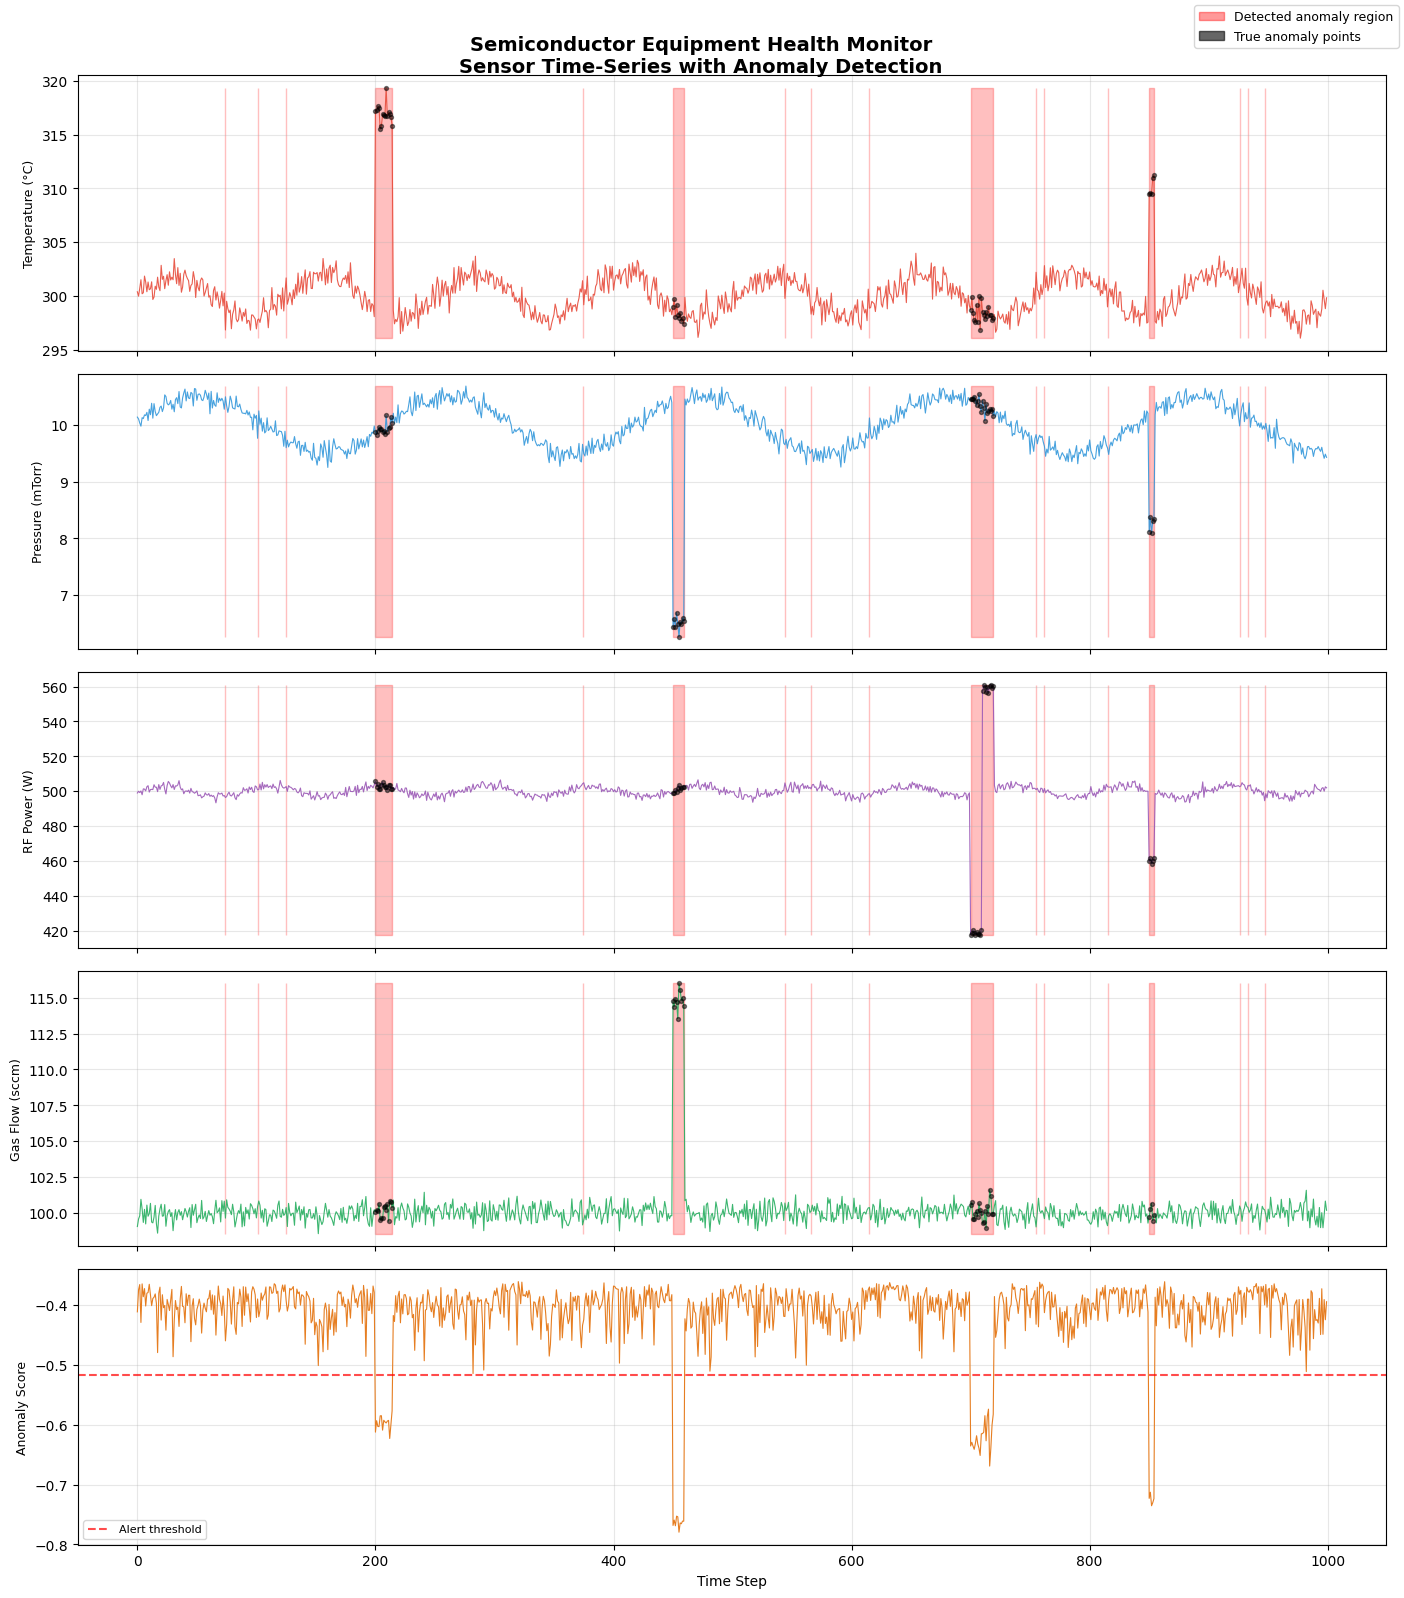

Plot saved.


In [31]:
# ── VISUALIZATION ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
fig.suptitle('Semiconductor Equipment Health Monitor\nSensor Time-Series with Anomaly Detection',
             fontsize=14, fontweight='bold', y=0.98)

sensor_labels = {
    'temperature': ('Temperature (°C)',  '#E74C3C'),
    'pressure':    ('Pressure (mTorr)',  '#3498DB'),
    'rf_power':    ('RF Power (W)',      '#9B59B6'),
    'gas_flow':    ('Gas Flow (sccm)',   '#27AE60'),
}

for ax, (sensor, (ylabel, color)) in zip(axes[:4], sensor_labels.items()):
    ax.plot(df['time'], df[sensor], color=color, linewidth=0.8, alpha=0.9)
    # Shade detected anomalies
    anomaly_mask = df['combined_anomaly'] == 1
    ax.fill_between(df['time'], df[sensor].min(), df[sensor].max(),
                    where=anomaly_mask, alpha=0.25, color='red', label='Detected anomaly')
    # Mark true anomalies
    true_mask = df['true_anomaly'] == 1
    ax.scatter(df.loc[true_mask, 'time'], df.loc[true_mask, sensor],
               color='black', s=8, zorder=5, alpha=0.5)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.3)

# Anomaly score panel
axes[4].plot(df['time'], df['anomaly_score'], color='#E67E22', linewidth=0.8)
axes[4].axhline(y=df['anomaly_score'].quantile(0.05), color='red',
                linestyle='--', alpha=0.7, label='Alert threshold')
axes[4].set_ylabel('Anomaly Score', fontsize=9)
axes[4].set_xlabel('Time Step', fontsize=10)
axes[4].legend(fontsize=8)
axes[4].grid(True, alpha=0.3)

red_patch   = mpatches.Patch(color='red',   alpha=0.4, label='Detected anomaly region')
black_patch = mpatches.Patch(color='black', alpha=0.6, label='True anomaly points')
fig.legend(handles=[red_patch, black_patch], loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('sensor_anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## Part 3 — LLM-Powered Diagnostic Explanation

Feed detected anomaly data to Claude API for plain-language diagnosis.
This simulates how an AI assistant would help an engineer understand what went wrong.

In [32]:
# ── IDENTIFY ANOMALY EVENTS ───────────────────────────────────────────────
def find_anomaly_events(df, min_gap=20):
    """Group consecutive anomaly points into discrete events."""
    events = []
    in_event = False
    start = 0
    for i, row in df.iterrows():
        if row['combined_anomaly'] == 1 and not in_event:
            start    = i
            in_event = True
        elif row['combined_anomaly'] == 0 and in_event:
            events.append((start, i - 1))
            in_event = False
    if in_event:
        events.append((start, len(df) - 1))
    # Merge events close together
    merged = [events[0]] if events else []
    for ev in events[1:]:
        if ev[0] - merged[-1][1] < min_gap:
            merged[-1] = (merged[-1][0], ev[1])
        else:
            merged.append(ev)
    return merged

events = find_anomaly_events(df)
print(f'Found {len(events)} anomaly events:')
for i, (start, end) in enumerate(events):
    window = df.iloc[start:end+1]
    print(f'  Event {i+1}: t={start}-{end} | '
          f'Temp: {window["temperature"].mean():.1f}°C | '
          f'Pressure: {window["pressure"].mean():.2f} mTorr | '
          f'RF: {window["rf_power"].mean():.1f}W | '
          f'Flow: {window["gas_flow"].mean():.1f} sccm')

Found 14 anomaly events:
  Event 1: t=74-74 | Temp: 296.8°C | Pressure: 10.50 mTorr | RF: 496.4W | Flow: 99.6 sccm
  Event 2: t=101-101 | Temp: 297.8°C | Pressure: 9.77 mTorr | RF: 500.8W | Flow: 100.4 sccm
  Event 3: t=125-125 | Temp: 301.7°C | Pressure: 9.60 mTorr | RF: 502.7W | Flow: 100.4 sccm
  Event 4: t=200-214 | Temp: 316.9°C | Pressure: 9.95 mTorr | RF: 502.8W | Flow: 100.2 sccm
  Event 5: t=374-374 | Temp: 301.4°C | Pressure: 9.66 mTorr | RF: 504.3W | Flow: 99.2 sccm
  Event 6: t=450-459 | Temp: 298.4°C | Pressure: 6.50 mTorr | RF: 501.2W | Flow: 114.8 sccm
  Event 7: t=544-544 | Temp: 299.8°C | Pressure: 9.65 mTorr | RF: 504.8W | Flow: 100.7 sccm
  Event 8: t=566-566 | Temp: 298.3°C | Pressure: 9.53 mTorr | RF: 501.3W | Flow: 100.1 sccm
  Event 9: t=615-615 | Temp: 298.9°C | Pressure: 10.12 mTorr | RF: 498.6W | Flow: 100.4 sccm
  Event 10: t=700-719 | Temp: 298.4°C | Pressure: 10.34 mTorr | RF: 488.9W | Flow: 100.1 sccm
  Event 11: t=755-762 | Temp: 301.0°C | Pressure: 9.75 

In [33]:
# ── LLM DIAGNOSTIC FUNCTION ───────────────────────────────────────────────
import requests
import json

def get_llm_diagnosis(event_data: dict) -> str:
    """
    Send anomaly event data to Claude API for plain-language diagnosis.
    Returns engineering-focused explanation of likely fault cause.
    """
    prompt = f"""You are an expert in semiconductor manufacturing equipment diagnostics.
    
A CVD (Chemical Vapor Deposition) chamber has triggered an anomaly alert with the following sensor readings:

- Time window: t={event_data['start']} to t={event_data['end']}
- Temperature: {event_data['temp_mean']:.1f}°C (baseline: 300°C, deviation: {event_data['temp_dev']:+.1f}°C)
- Pressure: {event_data['pressure_mean']:.2f} mTorr (baseline: 10 mTorr, deviation: {event_data['pressure_dev']:+.2f} mTorr)
- RF Power: {event_data['rf_mean']:.1f}W (baseline: 500W, deviation: {event_data['rf_dev']:+.1f}W)
- Gas Flow: {event_data['flow_mean']:.1f} sccm (baseline: 100 sccm, deviation: {event_data['flow_dev']:+.1f} sccm)

Based on these sensor deviations and your knowledge of semiconductor equipment physics:
1. What is the most likely fault or process anomaly?
2. What physical mechanism explains this sensor pattern?
3. What immediate action should the process engineer take?

Be concise and specific. Answer in 3-4 sentences."""

    response = requests.post(
        'https://api.anthropic.com/v1/messages',
        headers={'Content-Type': 'application/json'},
        json={
            'model': 'claude-sonnet-4-6',
            'max_tokens': 300,
            'messages': [{'role': 'user', 'content': prompt}]
        }
    )
    return response.json()['content'][0]['text']


def prepare_event_data(df, start, end):
    """Extract summary statistics for an anomaly event."""
    window = df.iloc[start:end+1]
    baselines = {'temperature': 300, 'pressure': 10, 'rf_power': 500, 'gas_flow': 100}
    return {
        'start':         start,
        'end':           end,
        'temp_mean':     window['temperature'].mean(),
        'temp_dev':      window['temperature'].mean() - baselines['temperature'],
        'pressure_mean': window['pressure'].mean(),
        'pressure_dev':  window['pressure'].mean() - baselines['pressure'],
        'rf_mean':       window['rf_power'].mean(),
        'rf_dev':        window['rf_power'].mean() - baselines['rf_power'],
        'flow_mean':     window['gas_flow'].mean(),
        'flow_dev':      window['gas_flow'].mean() - baselines['gas_flow'],
    }

print('LLM diagnostic function ready.')

LLM diagnostic function ready.


In [34]:
# ── RUN DIAGNOSTICS ON ALL EVENTS ────────────────────────────────────────
print('=' * 65)
print('SEMICONDUCTOR EQUIPMENT HEALTH MONITOR — DIAGNOSTIC REPORT')
print('=' * 65)

for i, (start, end) in enumerate(events):
    event_data = prepare_event_data(df, start, end)
    print(f'\n🔴 ANOMALY EVENT {i+1} | Time steps {start}–{end}')
    print(f'   Temp: {event_data["temp_dev"]:+.1f}°C  '
          f'Pressure: {event_data["pressure_dev"]:+.2f} mTorr  '
          f'RF: {event_data["rf_dev"]:+.1f}W  '
          f'Flow: {event_data["flow_dev"]:+.1f} sccm')
    print('\n   🤖 LLM Diagnosis:')
    try:
        diagnosis = get_llm_diagnosis(event_data)
        for line in diagnosis.split('\n'):
            print(f'   {line}')
    except Exception as e:
        print(f'   [API call failed: {e}]')
        print('   [Set up Anthropic API key to enable LLM diagnostics]')
    print('-' * 65)

SEMICONDUCTOR EQUIPMENT HEALTH MONITOR — DIAGNOSTIC REPORT

🔴 ANOMALY EVENT 1 | Time steps 74–74
   Temp: -3.2°C  Pressure: +0.50 mTorr  RF: -3.6W  Flow: -0.4 sccm

   🤖 LLM Diagnosis:
   [API call failed: 'content']
   [Set up Anthropic API key to enable LLM diagnostics]
-----------------------------------------------------------------

🔴 ANOMALY EVENT 2 | Time steps 101–101
   Temp: -2.2°C  Pressure: -0.23 mTorr  RF: +0.8W  Flow: +0.4 sccm

   🤖 LLM Diagnosis:
   [API call failed: 'content']
   [Set up Anthropic API key to enable LLM diagnostics]
-----------------------------------------------------------------

🔴 ANOMALY EVENT 3 | Time steps 125–125
   Temp: +1.7°C  Pressure: -0.40 mTorr  RF: +2.7W  Flow: +0.4 sccm

   🤖 LLM Diagnosis:
   [API call failed: 'content']
   [Set up Anthropic API key to enable LLM diagnostics]
-----------------------------------------------------------------

🔴 ANOMALY EVENT 4 | Time steps 200–214
   Temp: +16.9°C  Pressure: -0.05 mTorr  RF: +2.8W  Flow:

## Summary & Next Steps

### What this project demonstrates
- **Physical systems thinking:** Sensors mapped to real semiconductor process physics
- **Time-series ML:** Statistical baseline + Isolation Forest for multivariate anomaly detection
- **GenAI integration:** LLM API for domain-specific diagnostic explanation
- **End-to-end pipeline:** From raw sensor data to actionable engineering insight

### Next Steps
1. Apply to real SECOM semiconductor dataset (UCI ML Repository)
2. Add LSTM autoencoder for sequence-aware anomaly detection
3. Fine-tune LLM on semiconductor equipment manuals for more precise diagnosis
4. Build interactive dashboard for real-time monitoring